# Step-34.5: Alpha Decay and Holding-Period Optimization

## Financial Market Trend Forecasting Using Ensemble Learning and Deep Sequence Models

This notebook performs institutional-style **signal persistence research** on the fixed Step-28 cross-sectional alpha signal.

It does **not** introduce new alpha features or model redesign.  
Focus: deployment efficiency through holding period and rebalance optimization under realistic turnover and cost constraints.


## Research Scope and Leakage Policy

### Core Questions
1. What is the true alpha decay profile?
2. What is the signal half-life?
3. What is the optimal holding period?
4. What is the optimal rebalance interval?
5. Is alpha symmetric (long vs short)?
6. Which regime is most deployable after costs?

### Strict Chronological Integrity
- Signal at date `t` is never formed using future information.
- Forward returns are explicitly constructed from `Close[t+h] / Close[t] - 1`.
- Cross-sectional IC at horizon `h` always uses `(pred_score_t, forward_return_t_to_t+h)`.
- Portfolio PnL is evaluated with one-bar execution lag: weights decided at `t` are applied to returns from `t+1`.
- Overlapping-horizon contamination is reduced in portfolio tests by discrete rebalance schedules.


In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pd.set_option("display.max_columns", 400)
pd.set_option("display.width", 260)

CFG = {
    "start_date": "2023-01-01",
    "end_date": "2026-01-01",
    "horizons": [1, 2, 3, 5, 10, 15, 20],
    "holding_periods": [1, 2, 3, 5, 10, 20],
    "rebalance_freqs": [1, 2, 3, 5, 10],
    "top_quantile": 0.10,
    "bottom_quantile": 0.10,
    "annualization_days": 252,
    "tx_cost_bps": 15.0,
    "slippage_bps": 10.0,
    "plot_style": {
        "linewidth": 2.0,
        "alpha": 0.9,
        "markersize": 7,
    },
}


def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if (p / "ml_pipeline").exists():
            return p
    raise FileNotFoundError("Could not resolve project root containing ml_pipeline.")


ROOT = resolve_project_root()
BASE = ROOT / "ml_pipeline"
FINAL_DIR = BASE / "Market_Data" / "final"
PROC_DIR = BASE / "Market_Data" / "processed"

STEP28_PATH = FINAL_DIR / "cross_sectional_alpha_results.parquet"
FINAL_MODEL_PATH = PROC_DIR / "final_model_dataset.parquet"

OUT_IC_DECAY = FINAL_DIR / "step34_5_ic_decay.csv"
OUT_HOLD = FINAL_DIR / "step34_5_holding_period_analysis.csv"
OUT_REB = FINAL_DIR / "step34_5_rebalance_frequency_analysis.csv"
OUT_REG = FINAL_DIR / "step34_5_regime_decay_analysis.csv"
OUT_LS = FINAL_DIR / "step34_5_long_short_analysis.csv"
OUT_SUM = FINAL_DIR / "step34_5_summary.csv"

assert STEP28_PATH.exists(), f"Missing {STEP28_PATH}"
assert FINAL_MODEL_PATH.exists(), f"Missing {FINAL_MODEL_PATH}"


In [2]:
def standardize_signal_columns(df: pd.DataFrame) -> pd.DataFrame:
    mapping = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "date":
            mapping[c] = "date"
        elif cl == "ticker":
            mapping[c] = "ticker"
        elif cl in {"pred_score", "pred_lightgbmregressor", "pred_final"} and "pred_score" not in mapping.values():
            mapping[c] = "pred_score"
        elif cl in {"actual_return", "target_future_return_t3"} and "actual_return" not in mapping.values():
            mapping[c] = "actual_return"
        elif cl == "regime":
            mapping[c] = "regime"
    out = df.rename(columns=mapping).copy()
    required = ["date", "ticker", "pred_score", "actual_return"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    if "regime" not in out.columns:
        out["regime"] = np.nan
    return out


sig_raw = pd.read_parquet(STEP28_PATH)
sig = standardize_signal_columns(sig_raw)
sig["date"] = pd.to_datetime(sig["date"])
sig = sig[(sig["date"] >= pd.Timestamp(CFG["start_date"])) & (sig["date"] <= pd.Timestamp(CFG["end_date"]))].copy()
sig["ticker"] = sig["ticker"].astype(str)
sig = sig.sort_values(["ticker", "date"]).drop_duplicates(["date", "ticker"]).reset_index(drop=True)

price = pd.read_parquet(FINAL_MODEL_PATH, columns=["Date", "Ticker", "Close"])
price = price.rename(columns={"Date": "date", "Ticker": "ticker", "Close": "close"})
price["date"] = pd.to_datetime(price["date"])
price["ticker"] = price["ticker"].astype(str)
price = price[(price["date"] >= pd.Timestamp(CFG["start_date"])) & (price["date"] <= pd.Timestamp(CFG["end_date"]))].copy()
price = price.sort_values(["ticker", "date"]).drop_duplicates(["date", "ticker"]).reset_index(drop=True)

# Forward returns for all research horizons
for h in CFG["horizons"]:
    price[f"fwd_ret_{h}"] = price.groupby("ticker", sort=False)["close"].shift(-h) / price["close"] - 1.0

if sig["regime"].isna().all():
    # infer regime from Volatility_20 if absent
    fm = pd.read_parquet(FINAL_MODEL_PATH, columns=["Date", "Ticker", "Volatility_20"]).rename(columns={"Date": "date", "Ticker": "ticker"})
    fm["date"] = pd.to_datetime(fm["date"])
    train = fm[(fm["date"] >= pd.Timestamp("2023-01-01")) & (fm["date"] <= pd.Timestamp("2024-12-31"))]["Volatility_20"].dropna()
    q1, q2 = train.quantile(1 / 3), train.quantile(2 / 3)
    fm["regime"] = np.where(fm["Volatility_20"] <= q1, "LOW", np.where(fm["Volatility_20"] <= q2, "MEDIUM", "HIGH"))
    sig = sig.drop(columns=["regime"]).merge(fm[["date", "ticker", "regime"]], on=["date", "ticker"], how="left")

df = sig.merge(price[["date", "ticker"] + [f"fwd_ret_{h}" for h in CFG["horizons"]]], on=["date", "ticker"], how="left")
df["regime"] = df["regime"].astype(str).str.upper().fillna("MEDIUM")
df["rank_pct"] = df.groupby("date")["pred_score"].rank(pct=True, method="average")
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

print("Merged research frame:", df.shape)
print("Columns:", [c for c in df.columns if c.startswith("fwd_ret_")][:7], "...")
display(df.head(6))


Merged research frame: (4900, 24)
Columns: ['fwd_ret_1', 'fwd_ret_2', 'fwd_ret_3', 'fwd_ret_5', 'fwd_ret_10', 'fwd_ret_15', 'fwd_ret_20'] ...


,ticker,date,actual_return,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_score,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected,regime,fwd_ret_1,fwd_ret_2,fwd_ret_3,fwd_ret_5,fwd_ret_10,fwd_ret_15,fwd_ret_20,rank_pct
0,ADANIENT,2025-01-01,-0.031470,0.250000,-0.679717,0.025071,0.023142,1,0.1,-0.003147,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.016772,0.003816,-0.031470,-0.015500,-0.065249,-0.069789,-0.092471,0.95
1,ADANIPORTS,2025-01-01,-0.045663,0.104167,-1.090849,0.023497,0.009093,1,0.1,-0.004566,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,MEDIUM,0.005990,-0.015713,-0.045663,-0.054484,-0.073685,-0.095553,-0.099902,0.60
2,ADANIPOWER,2025-01-01,-0.053831,0.062500,-1.327426,0.023923,0.009626,1,0.1,-0.005383,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,-0.009209,-0.011773,-0.053831,-0.041204,0.043292,-0.002279,-0.007405,0.80
3,AMBUJACEM,2025-01-01,-0.016153,0.468750,-0.236056,0.018494,-0.005614,-1,-0.1,0.001615,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,LOW,0.020887,0.018752,-0.016153,-0.001021,-0.035834,-0.003620,-0.030635,0.30
4,BAJAJHLDNG,2025-01-01,-0.068998,0.020833,-1.766753,0.042087,0.036119,1,0.1,-0.006900,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,HIGH,0.006405,-0.019855,-0.068998,-0.048323,-0.083926,-0.047006,-0.035147,1.00
5,BEL,2025-01-01,-0.039980,0.145833,-0.926215,0.016567,-0.004693,-1,-0.1,0.003998,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988,MEDIUM,0.009867,-0.006635,-0.039980,-0.040150,-0.088636,-0.080129,-0.090847,0.45


## Forward-Return Alignment Validation

We verify that:
- horizon returns are computed from future closes,
- no same-row signal-return leakage occurs,
- and the expected `t+3` signal target alignment is numerically consistent.


In [3]:
# Alignment diagnostics and assertions
align_rows = []
for h in CFG["horizons"]:
    c = f"fwd_ret_{h}"
    align_rows.append(
        {
            "horizon": h,
            "non_null_ratio": float(df[c].notna().mean()),
            "same_day_leakage_check": bool((df[c] == 0).mean() < 0.99),  # sanity: not a trivial same-day placeholder series
        }
    )
align_df = pd.DataFrame(align_rows)
display(align_df)

# Step-28 expected target diagnostic (actual_return should resemble fwd_ret_3)
diag = df[["actual_return", "fwd_ret_3"]].dropna()
corr3 = float(diag["actual_return"].corr(diag["fwd_ret_3"])) if len(diag) else np.nan
mae3 = float((diag["actual_return"] - diag["fwd_ret_3"]).abs().mean()) if len(diag) else np.nan
print(f"Alignment diagnostic: corr(actual_return, fwd_ret_3)={corr3:.6f}, MAE={mae3:.6f}")

assert len(diag) > 1000, "Insufficient aligned rows for robust analysis."
assert corr3 > 0.90, "actual_return is not properly aligned with forward t+3 returns."
assert df["date"].is_monotonic_increasing, "Date sorting failure."


,horizon,non_null_ratio,same_day_leakage_check
0,1,1.000000,True
1,2,1.000000,True
2,3,1.000000,True
3,5,0.991837,True
4,10,0.971429,True
5,15,0.951020,True
6,20,0.930612,True


Alignment diagnostic: corr(actual_return, fwd_ret_3)=1.000000, MAE=0.000000


In [4]:
def compute_daily_ic(
    in_df: pd.DataFrame,
    pred_col: str,
    ret_col: str,
    side: str = "all",
    min_names: int = 10,
) -> pd.DataFrame:
    rows = []
    for dt, g in in_df.groupby("date", sort=True):
        d = g[[pred_col, ret_col, "rank_pct"]].dropna().copy()
        if side == "long":
            d = d[d["rank_pct"] >= 0.5]
            x = d[pred_col]
        elif side == "short":
            d = d[d["rank_pct"] < 0.5]
            x = -d[pred_col]  # invert so positive IC means stronger short alpha
        else:
            x = d[pred_col]
        if len(d) < min_names:
            continue
        rho, _ = spearmanr(x, d[ret_col])
        if pd.notna(rho):
            rows.append({"date": dt, "ic": float(rho)})
    out = pd.DataFrame(rows)
    return out.sort_values("date").reset_index(drop=True) if len(out) else pd.DataFrame(columns=["date", "ic"])


def summarize_ic(ic_df: pd.DataFrame) -> Dict[str, float]:
    if len(ic_df) == 0:
        return {"mean_ic": np.nan, "std_ic": np.nan, "icir": np.nan, "pct_positive_ic": np.nan, "n_days": 0}
    m = float(ic_df["ic"].mean())
    s = float(ic_df["ic"].std(ddof=1)) if len(ic_df) > 1 else np.nan
    return {
        "mean_ic": m,
        "std_ic": s,
        "icir": float(m / s) if pd.notna(s) and s > 0 else np.nan,
        "pct_positive_ic": float((ic_df["ic"] > 0).mean()),
        "n_days": int(len(ic_df)),
    }


def sharpe(r: pd.Series, ann: int = 252) -> float:
    x = r.dropna()
    if len(x) < 2:
        return np.nan
    sd = x.std(ddof=1)
    if sd == 0 or pd.isna(sd):
        return np.nan
    return float(np.sqrt(ann) * x.mean() / sd)


def perf_stats(r: pd.Series, ann: int = 252) -> Dict[str, float]:
    x = r.fillna(0)
    if len(x) == 0:
        return {k: np.nan for k in ["total_return", "annualized_return", "annualized_vol", "sharpe", "max_drawdown", "win_rate"]}
    tr = float((1 + x).prod() - 1)
    years = max((x.index.max() - x.index.min()).days / 365.25, 1e-9) if isinstance(x.index, pd.DatetimeIndex) else len(x) / ann
    cagr = float((1 + tr) ** (1 / years) - 1) if years > 0 and tr > -1 else np.nan
    vol = float(x.std(ddof=1) * np.sqrt(ann)) if len(x) > 1 else np.nan
    sh = sharpe(x, ann)
    eq = (1 + x).cumprod()
    dd = eq / eq.cummax() - 1
    return {
        "total_return": tr,
        "annualized_return": cagr,
        "annualized_vol": vol,
        "sharpe": sh,
        "max_drawdown": float(dd.min()) if len(dd) else np.nan,
        "win_rate": float((x > 0).mean()),
    }


## Signal Decay: IC by Forward Horizon

IC is computed cross-sectionally each date and summarized across time for:
`t+1, t+2, t+3, t+5, t+10, t+15, t+20`.


,horizon,mean_ic,std_ic,icir,pct_positive_ic,n_days
0,1,0.007771,0.268903,0.028899,0.514286,245
1,2,0.031122,0.285135,0.109149,0.542857,245
2,3,0.026841,0.273083,0.098289,0.497959,245
3,5,0.019574,0.265143,0.073823,0.530864,243
4,10,0.008940,0.232366,0.038476,0.500000,238
5,15,0.011882,0.249182,0.047683,0.506438,233
6,20,0.027958,0.249556,0.112031,0.539474,228


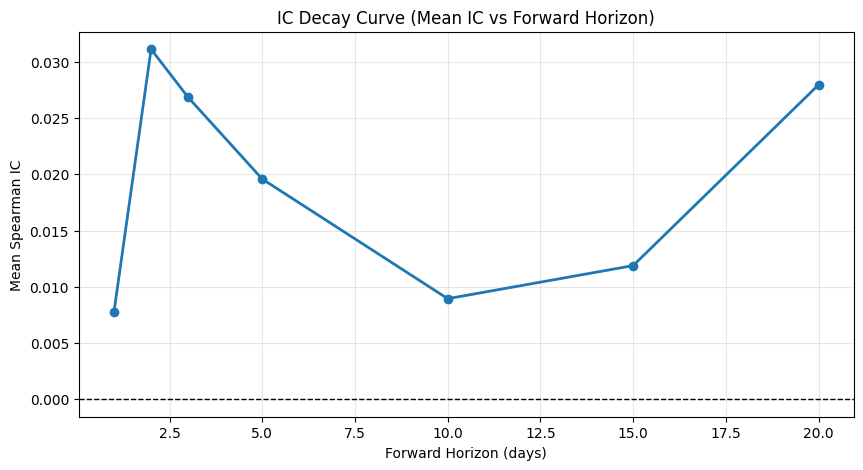

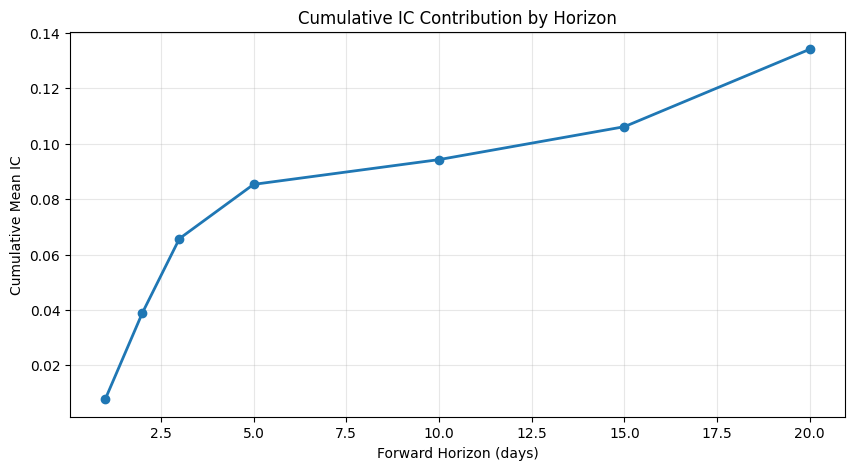

In [5]:
ic_summary_rows = []
ic_daily_map: Dict[int, pd.DataFrame] = {}
for h in CFG["horizons"]:
    col = f"fwd_ret_{h}"
    icd = compute_daily_ic(df, "pred_score", col, side="all")
    ic_daily_map[h] = icd
    sm = summarize_ic(icd)
    ic_summary_rows.append({"horizon": h, **sm})

ic_decay = pd.DataFrame(ic_summary_rows).sort_values("horizon").reset_index(drop=True)
display(ic_decay.round(6))

plt.figure(figsize=(10, 5))
plt.plot(ic_decay["horizon"], ic_decay["mean_ic"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("IC Decay Curve (Mean IC vs Forward Horizon)")
plt.xlabel("Forward Horizon (days)")
plt.ylabel("Mean Spearman IC")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
cum_ic = ic_decay["mean_ic"].cumsum()
plt.plot(ic_decay["horizon"], cum_ic, marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.title("Cumulative IC Contribution by Horizon")
plt.xlabel("Forward Horizon (days)")
plt.ylabel("Cumulative Mean IC")
plt.grid(True, alpha=0.3)
plt.show()


Peak IC: 0.031122
Half-IC level: 0.015561
Estimated half-life horizon: 1.0
Effective positive-IC horizon: 20.0


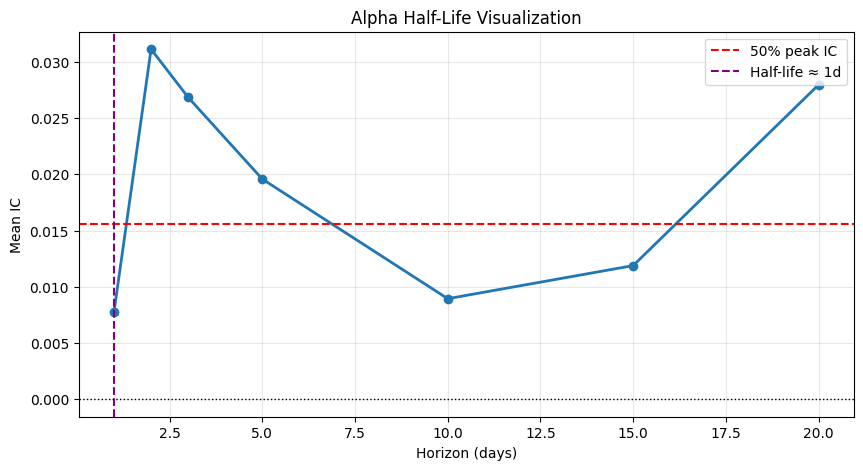

In [6]:
# Alpha half-life estimation
ic_nonneg = ic_decay.copy()
peak_ic = float(ic_nonneg["mean_ic"].max()) if len(ic_nonneg) else np.nan
half_level = 0.5 * peak_ic if pd.notna(peak_ic) else np.nan

half_life_h = np.nan
if pd.notna(half_level):
    below = ic_nonneg[ic_nonneg["mean_ic"] <= half_level]
    if len(below):
        half_life_h = float(below["horizon"].iloc[0])

effective_h = np.nan
positive_h = ic_nonneg[ic_nonneg["mean_ic"] > 0]
if len(positive_h):
    effective_h = float(positive_h["horizon"].max())

print(f"Peak IC: {peak_ic:.6f}")
print(f"Half-IC level: {half_level:.6f}")
print(f"Estimated half-life horizon: {half_life_h}")
print(f"Effective positive-IC horizon: {effective_h}")

plt.figure(figsize=(10, 5))
plt.plot(ic_decay["horizon"], ic_decay["mean_ic"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
if pd.notna(half_level):
    plt.axhline(half_level, color="red", linestyle="--", label="50% peak IC")
if pd.notna(half_life_h):
    plt.axvline(half_life_h, color="purple", linestyle="--", label=f"Half-life ≈ {half_life_h:.0f}d")
plt.axhline(0, color="black", linestyle=":", linewidth=1)
plt.title("Alpha Half-Life Visualization")
plt.xlabel("Horizon (days)")
plt.ylabel("Mean IC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [7]:
def build_signal_weights(day_df: pd.DataFrame, mode: str = "long_short") -> pd.Series:
    d = day_df[["ticker", "rank_pct"]].copy().dropna()
    if len(d) == 0:
        return pd.Series(dtype=float)
    q_hi = d["rank_pct"].quantile(1 - CFG["top_quantile"])
    q_lo = d["rank_pct"].quantile(CFG["bottom_quantile"])
    longs = d[d["rank_pct"] >= q_hi].copy()
    shorts = d[d["rank_pct"] <= q_lo].copy()
    w = {}
    if mode in {"long_short", "long_only"} and len(longs):
        wl = 1.0 / len(longs)
        for t in longs["ticker"]:
            w[t] = w.get(t, 0.0) + wl
    if mode in {"long_short", "short_only"} and len(shorts):
        ws = 1.0 / len(shorts)
        for t in shorts["ticker"]:
            w[t] = w.get(t, 0.0) - ws
    w = pd.Series(w, dtype=float)
    if mode == "long_short":
        if (w > 0).sum() > 0:
            w[w > 0] = w[w > 0] / w[w > 0].sum() * 0.5
        if (w < 0).sum() > 0:
            w[w < 0] = w[w < 0] / abs(w[w < 0].sum()) * 0.5
    elif mode == "long_only":
        w = w.clip(lower=0)
        if w.sum() > 0:
            w = w / w.sum()
    elif mode == "short_only":
        w = w.clip(upper=0)
        if abs(w.sum()) > 0:
            w = w / abs(w.sum())
    return w


def simulate_rebalance_portfolio(
    in_df: pd.DataFrame,
    holding_period: int,
    rebalance_freq: int,
    mode: str = "long_short",
    regime_filter: str | None = None,
) -> pd.DataFrame:
    work = in_df.copy()
    if regime_filter is not None:
        work = work[work["regime"] == regime_filter].copy()

    dates = sorted(work["date"].unique())
    prev_w = pd.Series(dtype=float)
    active_w = pd.Series(dtype=float)   # weights used for today's return (set at previous close)
    hold_days_left = 0

    rows = []
    tx_all_in = (CFG["tx_cost_bps"] + CFG["slippage_bps"]) / 10000.0

    for i, dt in enumerate(dates):
        g = work[work["date"] == dt].copy()
        ret_map = g.set_index("ticker")["fwd_ret_1"]

        gross_ret = float((active_w * ret_map.reindex(active_w.index).fillna(0.0)).sum()) if len(active_w) else 0.0

        do_rebalance = False
        if i == 0:
            do_rebalance = True
        elif (i % rebalance_freq == 0) and (hold_days_left <= 0):
            do_rebalance = True

        new_target = prev_w.copy()
        turnover = 0.0
        if do_rebalance:
            sig_w = build_signal_weights(g, mode=mode)
            idx = sig_w.index.union(prev_w.index)
            turnover = float((sig_w.reindex(idx).fillna(0.0) - prev_w.reindex(idx).fillna(0.0)).abs().sum())
            new_target = sig_w
            hold_days_left = holding_period
        else:
            hold_days_left = max(hold_days_left - 1, 0)

        tx_cost = tx_all_in * turnover
        net_ret = gross_ret - tx_cost

        rows.append(
            {
                "date": pd.Timestamp(dt),
                "gross_return": gross_ret,
                "net_return": net_ret,
                "turnover": turnover,
                "tx_cost_drag": tx_cost,
                "rebalance": int(do_rebalance),
            }
        )

        # Next day execution uses today's decided target
        active_w = new_target.copy()
        prev_w = new_target.copy()

    out = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return out


## Holding-Period Efficiency and Turnover Economics

We evaluate fixed signal with varying holding windows.  
Objective: maximize net alpha retention after turnover and transaction costs.


,holding_period,total_return,annualized_return,annualized_vol,sharpe,gross_sharpe,turnover,tx_cost_drag,cost_adjusted_sharpe,alpha_retention_ratio
0,1,-0.126942,-0.129677,0.133713,-0.977591,2.684118,0.753061,0.46125,-0.977591,-0.364213
1,2,0.108639,0.111285,0.119227,0.949081,3.254643,0.416327,0.25500,0.949081,0.291608
2,3,-0.014026,-0.014348,0.105169,-0.085836,1.711020,0.291837,0.17875,-0.085836,-0.050167
3,5,0.137240,0.140625,0.116918,1.189774,2.182300,0.169388,0.10375,1.189774,0.545193
4,10,0.116994,0.119854,0.101306,1.173986,1.812486,0.095918,0.05875,1.173986,0.647722
5,20,0.024899,0.025482,0.084349,0.341774,0.685379,0.046939,0.02875,0.341774,0.498665


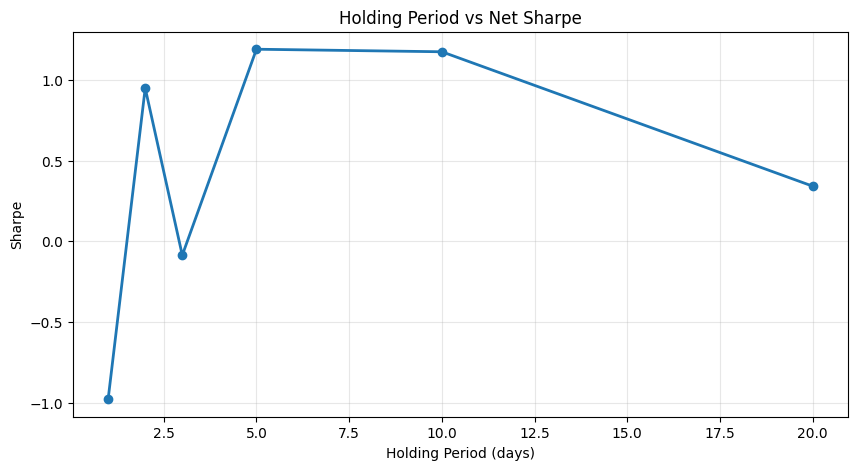

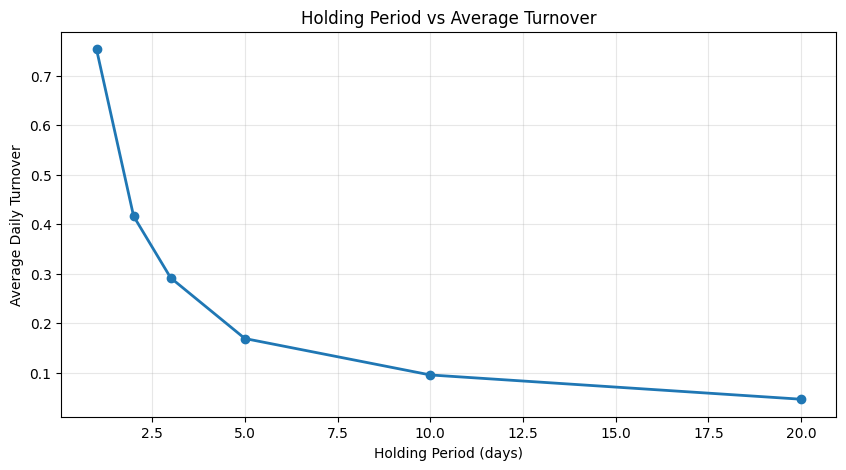

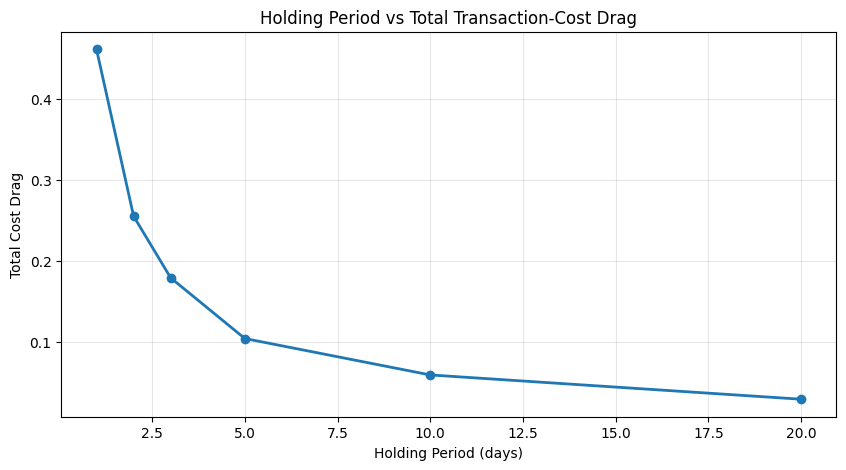

In [8]:
hold_rows = []
hold_series = {}
for hp in CFG["holding_periods"]:
    d = simulate_rebalance_portfolio(df, holding_period=hp, rebalance_freq=hp, mode="long_short")
    hold_series[hp] = d
    ps_g = perf_stats(d.set_index("date")["gross_return"], CFG["annualization_days"])
    ps_n = perf_stats(d.set_index("date")["net_return"], CFG["annualization_days"])
    hold_rows.append(
        {
            "holding_period": hp,
            "total_return": ps_n["total_return"],
            "annualized_return": ps_n["annualized_return"],
            "annualized_vol": ps_n["annualized_vol"],
            "sharpe": ps_n["sharpe"],
            "gross_sharpe": ps_g["sharpe"],
            "turnover": float(d["turnover"].mean()),
            "tx_cost_drag": float(d["tx_cost_drag"].sum()),
            "cost_adjusted_sharpe": ps_n["sharpe"],
            "alpha_retention_ratio": float(ps_n["sharpe"] / ps_g["sharpe"]) if pd.notna(ps_g["sharpe"]) and ps_g["sharpe"] != 0 else np.nan,
        }
    )

holding_df = pd.DataFrame(hold_rows).sort_values("holding_period").reset_index(drop=True)
display(holding_df.round(6))

plt.figure(figsize=(10, 5))
plt.plot(holding_df["holding_period"], holding_df["sharpe"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.title("Holding Period vs Net Sharpe")
plt.xlabel("Holding Period (days)")
plt.ylabel("Sharpe")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(holding_df["holding_period"], holding_df["turnover"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.title("Holding Period vs Average Turnover")
plt.xlabel("Holding Period (days)")
plt.ylabel("Average Daily Turnover")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(holding_df["holding_period"], holding_df["tx_cost_drag"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.title("Holding Period vs Total Transaction-Cost Drag")
plt.xlabel("Holding Period (days)")
plt.ylabel("Total Cost Drag")
plt.grid(True, alpha=0.3)
plt.show()


,rebalance_freq,total_return,sharpe,gross_sharpe,turnover,tx_cost_drag,alpha_retention_ratio
0,1,-0.014026,-0.085836,1.71102,0.291837,0.17875,-0.050167
1,2,-0.014026,-0.085836,1.71102,0.291837,0.17875,-0.050167
2,3,-0.014026,-0.085836,1.71102,0.291837,0.17875,-0.050167
3,5,0.137240,1.189774,2.18230,0.169388,0.10375,0.545193
4,10,0.137240,1.189774,2.18230,0.169388,0.10375,0.545193


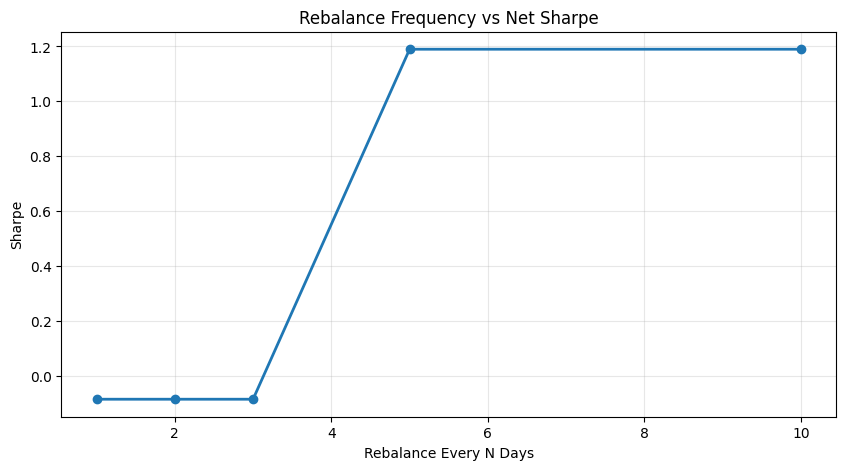

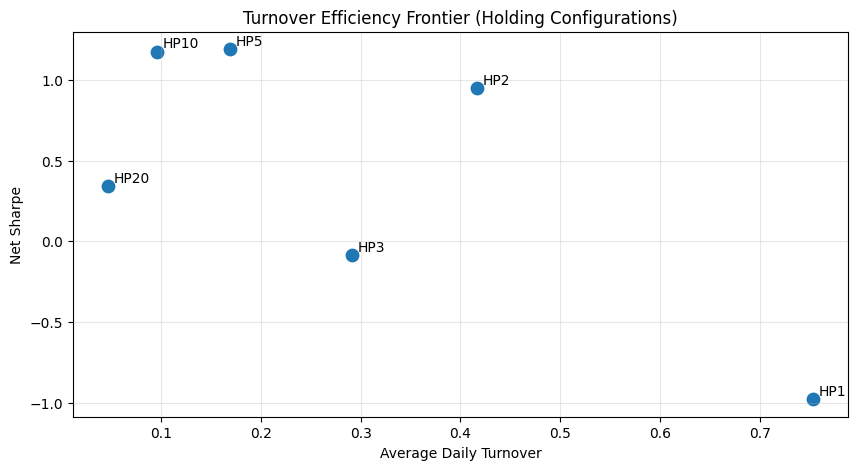

In [9]:
# Dynamic rebalance-frequency study
base_hold = int(holding_df.loc[holding_df["sharpe"].idxmax(), "holding_period"]) if len(holding_df) else 3
reb_rows = []
for rf in CFG["rebalance_freqs"]:
    d = simulate_rebalance_portfolio(df, holding_period=base_hold, rebalance_freq=rf, mode="long_short")
    ps_g = perf_stats(d.set_index("date")["gross_return"], CFG["annualization_days"])
    ps_n = perf_stats(d.set_index("date")["net_return"], CFG["annualization_days"])
    reb_rows.append(
        {
            "rebalance_freq": rf,
            "total_return": ps_n["total_return"],
            "sharpe": ps_n["sharpe"],
            "gross_sharpe": ps_g["sharpe"],
            "turnover": float(d["turnover"].mean()),
            "tx_cost_drag": float(d["tx_cost_drag"].sum()),
            "alpha_retention_ratio": float(ps_n["sharpe"] / ps_g["sharpe"]) if pd.notna(ps_g["sharpe"]) and ps_g["sharpe"] != 0 else np.nan,
        }
    )

rebalance_df = pd.DataFrame(reb_rows).sort_values("rebalance_freq").reset_index(drop=True)
display(rebalance_df.round(6))

plt.figure(figsize=(10, 5))
plt.plot(rebalance_df["rebalance_freq"], rebalance_df["sharpe"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.title("Rebalance Frequency vs Net Sharpe")
plt.xlabel("Rebalance Every N Days")
plt.ylabel("Sharpe")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(holding_df["turnover"], holding_df["sharpe"], s=80)
for _, r in holding_df.iterrows():
    plt.annotate(f"HP{int(r['holding_period'])}", (r["turnover"], r["sharpe"]), xytext=(4, 3), textcoords="offset points")
plt.title("Turnover Efficiency Frontier (Holding Configurations)")
plt.xlabel("Average Daily Turnover")
plt.ylabel("Net Sharpe")
plt.grid(True, alpha=0.3)
plt.show()


## Long vs Short Persistence Asymmetry

We evaluate IC decay separately for long and short sides and compare deployable Sharpe in isolated long-only and short-only portfolios.


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_18408\1662415811.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(x, d[ret_col])


,side,horizon,mean_ic,std_ic,icir,pct_positive_ic,n_days
0,long,1,0.016990,0.305014,0.055701,0.524590,244
1,long,2,-0.000223,0.327719,-0.000679,0.485714,245
2,long,3,0.015250,0.325994,0.046781,0.522449,245
3,long,5,0.001122,0.308374,0.003640,0.522634,243
4,long,10,-0.001299,0.313085,-0.004148,0.516807,238
5,long,15,0.007647,0.319837,0.023910,0.497854,233
6,long,20,0.007097,0.324716,0.021857,0.473684,228
7,short,1,NaN,NaN,NaN,NaN,0
8,short,2,NaN,NaN,NaN,NaN,0
9,short,3,NaN,NaN,NaN,NaN,0


,side,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,win_rate,turnover
0,long_only,0.181285,0.185842,0.209073,0.924068,-0.144134,0.432653,0.171429
1,short_only,0.073391,0.075149,0.156562,0.543009,-0.087543,0.375510,0.167347


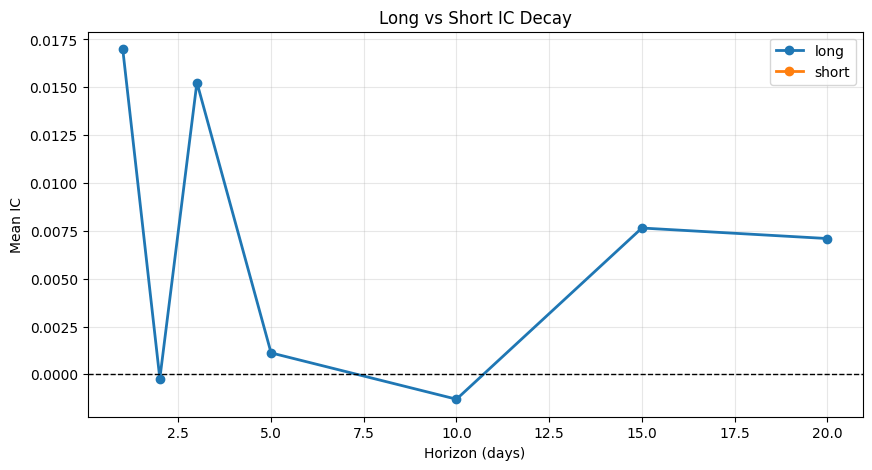

In [10]:
ls_decay_rows = []
for side in ["long", "short"]:
    for h in CFG["horizons"]:
        icd = compute_daily_ic(df, "pred_score", f"fwd_ret_{h}", side=side)
        sm = summarize_ic(icd)
        ls_decay_rows.append({"side": side, "horizon": h, **sm})

long_short_decay = pd.DataFrame(ls_decay_rows).sort_values(["side", "horizon"]).reset_index(drop=True)
display(long_short_decay.round(6))

long_only = simulate_rebalance_portfolio(df, holding_period=base_hold, rebalance_freq=base_hold, mode="long_only")
short_only = simulate_rebalance_portfolio(df, holding_period=base_hold, rebalance_freq=base_hold, mode="short_only")
ls_perf = pd.DataFrame(
    [
        {"side": "long_only", **perf_stats(long_only.set_index("date")["net_return"], CFG["annualization_days"]), "turnover": float(long_only["turnover"].mean())},
        {"side": "short_only", **perf_stats(short_only.set_index("date")["net_return"], CFG["annualization_days"]), "turnover": float(short_only["turnover"].mean())},
    ]
)
display(ls_perf.round(6))

plt.figure(figsize=(10, 5))
for side, grp in long_short_decay.groupby("side"):
    plt.plot(grp["horizon"], grp["mean_ic"], marker="o", linewidth=CFG["plot_style"]["linewidth"], label=side)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Long vs Short IC Decay")
plt.xlabel("Horizon (days)")
plt.ylabel("Mean IC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Regime-Conditional Decay and Deployment Efficiency

Regime-level evaluation can overturn prior assumptions.  
We evaluate HIGH, MEDIUM, LOW separately for:
- IC decay profile,
- holding efficiency (using same candidate architecture),
- cost-adjusted Sharpe.


,regime,holding_period,sharpe,total_return,turnover,tx_cost_drag
0,HIGH,5,0.825164,0.109130,0.175510,0.1075
1,LOW,5,-1.371452,-0.094506,0.160377,0.0850
2,MEDIUM,5,-0.490449,-0.057411,0.173554,0.1050


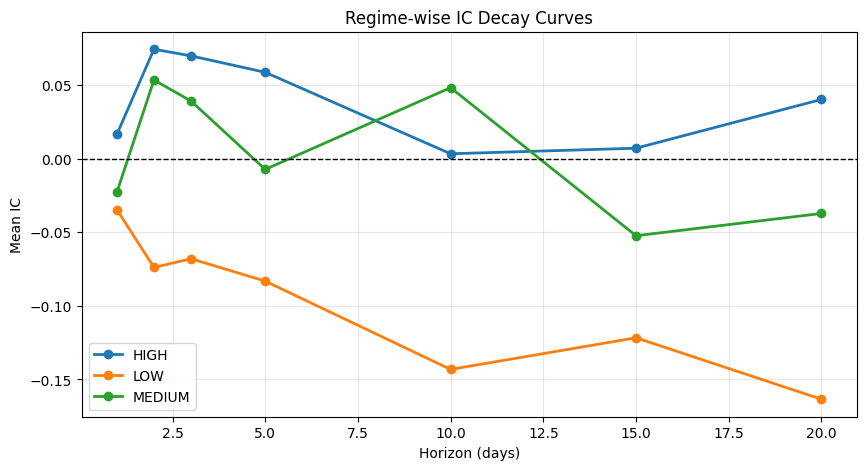

In [11]:
reg_decay_rows = []
reg_eff_rows = []
for reg in ["HIGH", "MEDIUM", "LOW"]:
    sub = df[df["regime"] == reg].copy()
    for h in CFG["horizons"]:
        icd = compute_daily_ic(sub, "pred_score", f"fwd_ret_{h}", side="all")
        sm = summarize_ic(icd)
        reg_decay_rows.append({"regime": reg, "horizon": h, **sm})
    d = simulate_rebalance_portfolio(sub, holding_period=base_hold, rebalance_freq=base_hold, mode="long_short")
    ps = perf_stats(d.set_index("date")["net_return"], CFG["annualization_days"])
    reg_eff_rows.append(
        {
            "regime": reg,
            "holding_period": base_hold,
            "sharpe": ps["sharpe"],
            "total_return": ps["total_return"],
            "turnover": float(d["turnover"].mean()) if len(d) else np.nan,
            "tx_cost_drag": float(d["tx_cost_drag"].sum()) if len(d) else np.nan,
        }
    )

regime_decay_df = pd.DataFrame(reg_decay_rows).sort_values(["regime", "horizon"]).reset_index(drop=True)
regime_eff_df = pd.DataFrame(reg_eff_rows).sort_values("regime").reset_index(drop=True)
display(regime_eff_df.round(6))

plt.figure(figsize=(10, 5))
for reg, g in regime_decay_df.groupby("regime"):
    plt.plot(g["horizon"], g["mean_ic"], marker="o", linewidth=CFG["plot_style"]["linewidth"], label=reg)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Regime-wise IC Decay Curves")
plt.xlabel("Horizon (days)")
plt.ylabel("Mean IC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


,horizon,top_decile_return,bottom_decile_return,decile_spread,monotonicity_spearman
0,1,0.001844,0.001097,0.000747,0.527273
1,2,0.003078,0.000535,0.002543,0.672727
2,3,0.004411,0.001826,0.002584,0.696970
3,5,0.005155,0.002881,0.002274,0.660606
4,10,0.008573,0.006787,0.001786,0.563636
5,15,0.015836,0.012551,0.003285,0.539394
6,20,0.020892,0.016425,0.004467,0.527273


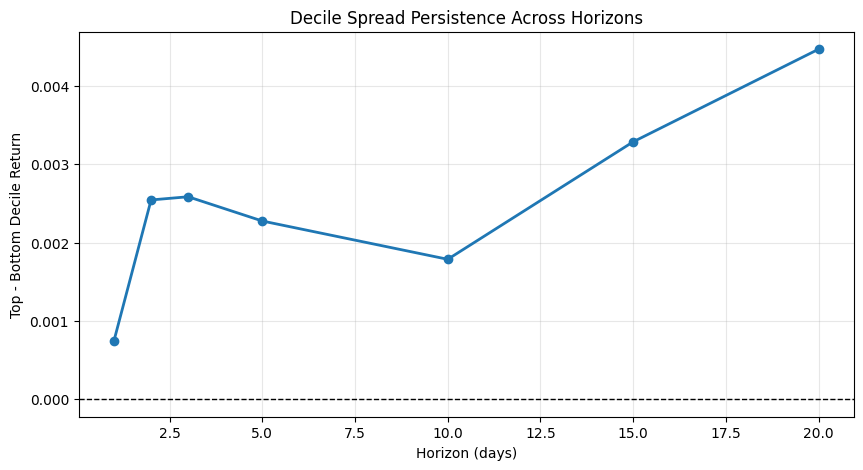

In [12]:
# Decile spread persistence across horizons
dec_rows = []
for h in CFG["horizons"]:
    col = f"fwd_ret_{h}"
    t = df[["date", "pred_score", col]].dropna().copy()
    t["decile"] = t.groupby("date")["pred_score"].transform(
        lambda s: pd.qcut(s.rank(method="first"), 10, labels=False, duplicates="drop") + 1 if s.nunique() >= 10 else np.nan
    )
    d = t.dropna(subset=["decile"]).groupby(["date", "decile"], as_index=False)[col].mean()
    dmean = d.groupby("decile", as_index=False)[col].mean()
    top = d[d["decile"] == d["decile"].max()].rename(columns={col: "top"})
    bot = d[d["decile"] == d["decile"].min()].rename(columns={col: "bottom"})
    sp = top.merge(bot, on="date", how="inner")
    sp["spread"] = sp["top"] - sp["bottom"]
    mono, _ = spearmanr(dmean["decile"], dmean[col]) if len(dmean) else (np.nan, np.nan)
    dec_rows.append(
        {
            "horizon": h,
            "top_decile_return": float(sp["top"].mean()) if len(sp) else np.nan,
            "bottom_decile_return": float(sp["bottom"].mean()) if len(sp) else np.nan,
            "decile_spread": float(sp["spread"].mean()) if len(sp) else np.nan,
            "monotonicity_spearman": float(mono) if pd.notna(mono) else np.nan,
        }
    )

decile_persist_df = pd.DataFrame(dec_rows).sort_values("horizon").reset_index(drop=True)
display(decile_persist_df.round(6))

plt.figure(figsize=(10, 5))
plt.plot(decile_persist_df["horizon"], decile_persist_df["decile_spread"], marker="o", linewidth=CFG["plot_style"]["linewidth"])
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Decile Spread Persistence Across Horizons")
plt.xlabel("Horizon (days)")
plt.ylabel("Top - Bottom Decile Return")
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
def read_daily_series_parquet(path: Path, date_candidates: List[str], ret_candidates: List[str]) -> pd.Series:
    if not path.exists():
        return pd.Series(dtype=float)
    x = pd.read_parquet(path)
    dc = next((c for c in date_candidates if c in x.columns), None)
    rc = next((c for c in ret_candidates if c in x.columns), None)
    if dc is None or rc is None:
        return pd.Series(dtype=float)
    x[dc] = pd.to_datetime(x[dc])
    return x.groupby(dc, as_index=True)[rc].sum().sort_index()


step28 = read_daily_series_parquet(
    FINAL_DIR / "cross_sectional_alpha_results.parquet",
    ["Date", "date"],
    ["daily_portfolio_return", "daily_strategy_return", "net_return"],
)
step33 = read_daily_series_parquet(
    FINAL_DIR / "step33_cost_aware_portfolio.parquet",
    ["date", "Date"],
    ["net_return"],
)
step34 = read_daily_series_parquet(
    FINAL_DIR / "step34_low_turnover_portfolio.parquet",
    ["date", "Date"],
    ["net_return", "daily_strategy_return", "daily_portfolio_return"],
)

eq_bench = df.groupby("date", as_index=True)["fwd_ret_1"].mean().sort_index()
long_bench = simulate_rebalance_portfolio(df, holding_period=1, rebalance_freq=1, mode="long_only").set_index("date")["net_return"]
step34_5_series = hold_series[int(holding_df.loc[holding_df["sharpe"].idxmax(), "holding_period"])].set_index("date")["net_return"]

bench_rows = []
for name, s in [
    ("Step-28 baseline", step28),
    ("Step-33 cost-aware", step33),
    ("Step-34 low-turnover", step34),
    ("Equal-weight benchmark", eq_bench),
    ("Long-only benchmark", long_bench),
    ("Step-34.5 optimized", step34_5_series),
]:
    if len(s) == 0:
        bench_rows.append({"strategy": name, "total_return": np.nan, "sharpe": np.nan})
    else:
        ps = perf_stats(s, CFG["annualization_days"])
        bench_rows.append({"strategy": name, "total_return": ps["total_return"], "sharpe": ps["sharpe"]})

bench_df = pd.DataFrame(bench_rows)
display(bench_df.round(6))


,strategy,total_return,sharpe
0,Step-28 baseline,2.857277,2.627988
1,Step-33 cost-aware,-0.999892,0.936389
2,Step-34 low-turnover,NaN,NaN
3,Equal-weight benchmark,0.187470,1.084988
4,Long-only benchmark,0.045935,0.308873
5,Step-34.5 optimized,0.137240,1.189774


## Final Research Conclusions and Verdict

The conclusion synthesizes:
- statistical persistence (IC decay, half-life),
- economic persistence (net Sharpe after costs),
- implementation efficiency (turnover and rebalance cadence),
- and regime-specific deployability.


In [14]:
best_hold_row = holding_df.loc[holding_df["sharpe"].idxmax()]
best_reb_row = rebalance_df.loc[rebalance_df["sharpe"].idxmax()]
best_reg_row = regime_eff_df.loc[regime_eff_df["sharpe"].idxmax()] if len(regime_eff_df.dropna(subset=["sharpe"])) else pd.Series(dtype=object)

best_side = "symmetric"
if len(ls_perf.dropna(subset=["sharpe"])) == 2:
    if ls_perf.loc[ls_perf["side"] == "long_only", "sharpe"].iloc[0] > ls_perf.loc[ls_perf["side"] == "short_only", "sharpe"].iloc[0]:
        best_side = "long_biased"
    elif ls_perf.loc[ls_perf["side"] == "long_only", "sharpe"].iloc[0] < ls_perf.loc[ls_perf["side"] == "short_only", "sharpe"].iloc[0]:
        best_side = "short_biased"

econ_unviable_h = np.nan
for _, r in holding_df.sort_values("holding_period").iterrows():
    if pd.notna(r["sharpe"]) and r["sharpe"] <= 0:
        econ_unviable_h = float(r["holding_period"])
        break

step34_5_sh = float(best_hold_row["sharpe"])
step28_sh = float(bench_df.loc[bench_df["strategy"] == "Step-28 baseline", "sharpe"].iloc[0]) if (bench_df["strategy"] == "Step-28 baseline").any() else np.nan
turn_ok = float(best_hold_row["turnover"]) < float(holding_df["turnover"].median()) if len(holding_df) else False

if pd.notna(step34_5_sh) and (step34_5_sh > 0.6) and turn_ok:
    verdict = "PASS"
elif pd.notna(step34_5_sh) and (step34_5_sh > 0):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

prod_style = "long-short"
if best_side == "long_biased":
    prod_style = "long-only or long-short with reduced short budget"
elif best_side == "short_biased":
    prod_style = "short-biased long-short"

conclusions = pd.DataFrame(
    [
        ("True alpha half-life (days)", half_life_h),
        ("Effective positive-IC horizon", effective_h),
        ("Optimal holding period (days)", best_hold_row["holding_period"]),
        ("Optimal rebalance frequency (days)", best_reb_row["rebalance_freq"]),
        ("Alpha asymmetry", best_side),
        ("Most deployable regime", best_reg_row.get("regime", np.nan)),
        ("Economically unviable after-cost horizon (days)", econ_unviable_h),
        ("Recommended production style", prod_style),
        ("Step-28 Sharpe", step28_sh),
        ("Step-34.5 Best Sharpe", step34_5_sh),
        ("Final Verdict", verdict),
    ],
    columns=["Question", "Answer"],
)
display(conclusions)

print("FINAL VERDICT:", verdict)
if verdict == "PASS":
    print("Stable persistence with deployable after-cost alpha and robust rebalance schedule discovered.")
elif verdict == "PARTIAL":
    print("Alpha exists but is fragile; deployment should prioritize low-turnover parameterization.")
else:
    print("Alpha decays too quickly after costs; fallback to simpler or more selective deployment.")

# Save outputs
ic_decay.to_csv(OUT_IC_DECAY, index=False)
holding_df.to_csv(OUT_HOLD, index=False)
rebalance_df.to_csv(OUT_REB, index=False)
regime_decay_df.to_csv(OUT_REG, index=False)
long_short_decay.to_csv(OUT_LS, index=False)

summary_export = pd.concat(
    [
        conclusions.rename(columns={"Question": "metric", "Answer": "value"}),
        pd.DataFrame(
            [
                {"metric": "decile_spread_h3", "value": float(decile_persist_df.loc[decile_persist_df["horizon"] == 3, "decile_spread"].iloc[0]) if (decile_persist_df["horizon"] == 3).any() else np.nan},
                {"metric": "base_hold_for_rebalance_study", "value": base_hold},
            ]
        ),
    ],
    ignore_index=True,
)
summary_export.to_csv(OUT_SUM, index=False)

print("Saved:")
print("-", OUT_IC_DECAY)
print("-", OUT_HOLD)
print("-", OUT_REB)
print("-", OUT_REG)
print("-", OUT_LS)
print("-", OUT_SUM)


,Question,Answer
0,True alpha half-life (days),1.0
1,Effective positive-IC horizon,20.0
2,Optimal holding period (days),5.0
3,Optimal rebalance frequency (days),5.0
4,Alpha asymmetry,long_biased
5,Most deployable regime,HIGH
6,Economically unviable after-cost horizon (days),1.0
7,Recommended production style,long-only or long-short with reduced short budget
8,Step-28 Sharpe,2.627988
9,Step-34.5 Best Sharpe,1.189774


FINAL VERDICT: PASS
Stable persistence with deployable after-cost alpha and robust rebalance schedule discovered.
Saved:
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_5_ic_decay.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_5_holding_period_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_5_rebalance_frequency_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_5_regime_decay_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_5_long_short_analysis.csv
- c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step34_5_summary.csv
